In [423]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# Step 3: Assign Column Names

In [426]:
columns = ['engine_id','cycle','op1','op2','op3'] + ['sensor_'+str(i) for i in range(1,22)]

In [428]:
print(columns)

['engine_id', 'cycle', 'op1', 'op2', 'op3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [430]:
train = pd.read_csv("train_FD001.txt", sep=r"\s+", header=None)
train.columns = columns

train.head()

,engine_id,cycle,op1,op2,op3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [431]:
train.shape

(20631, 26)

In [432]:
max_cycle = train.groupby('engine_id')['cycle'].max()

train = train.merge(max_cycle.to_frame(name='max_cycle'), on='engine_id')

train['RUL'] = train['max_cycle'] - train['cycle']

train.head()

,engine_id,cycle,op1,op2,op3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [433]:
train.shape

(20631, 28)

 # Step 5: Data Cleaning

In [435]:
unique_counts =train.nunique()
constant_columns = unique_counts[unique_counts == 1].index.tolist()

train.drop(constant_columns, axis=1, inplace=True)

In [436]:
unique_counts
#constant_columns

engine_id     100
cycle         362
op1           158
op2            13
op3             1
sensor_1        1
sensor_2      310
sensor_3     3012
sensor_4     4051
sensor_5        1
sensor_6        2
sensor_7      513
sensor_8       53
sensor_9     6403
sensor_10       1
sensor_11     159
sensor_12     427
sensor_13      56
sensor_14    6078
sensor_15    1918
sensor_16       1
sensor_17      13
sensor_18       1
sensor_19       1
sensor_20     120
sensor_21    4745
max_cycle      66
RUL           362
dtype: int64

In [437]:
constant_columns

['op3',
 'sensor_1',
 'sensor_5',
 'sensor_10',
 'sensor_16',
 'sensor_18',
 'sensor_19']

In [438]:
train.shape

(20631, 21)

Step 6: Exploratory Data Analysis (EDA)

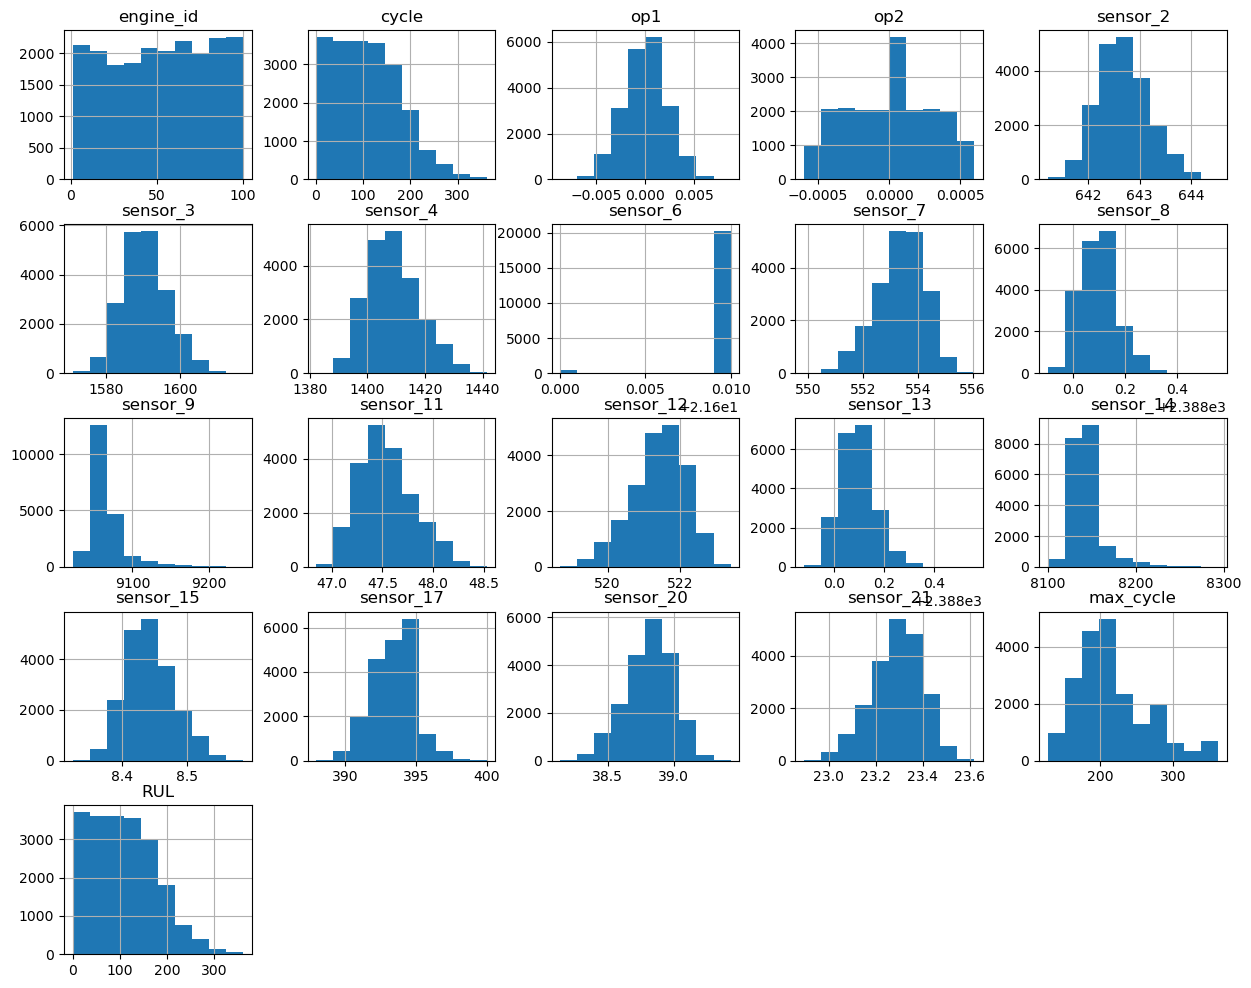

In [441]:
train.hist(figsize=(15,12))
plt.show()

<Axes: >

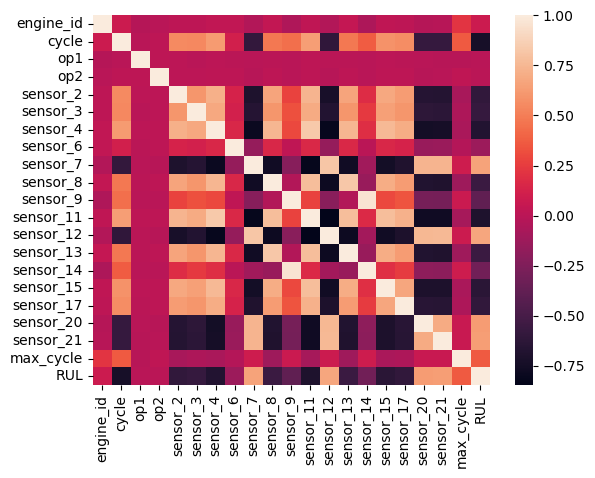

In [444]:
corr_matrix = train.corr()

sns.heatmap(corr_matrix)

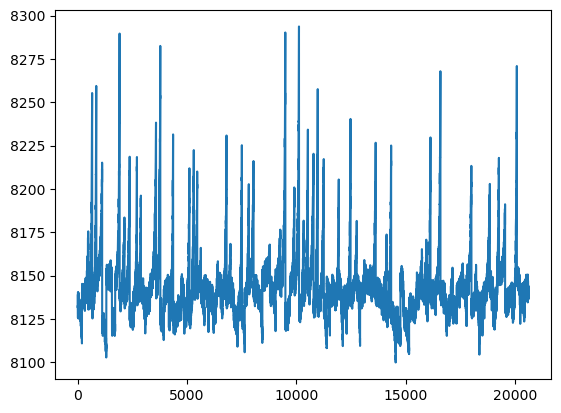

In [448]:
plt.plot(train['sensor_14'])

In [451]:
#Step 7: Feature Selection
train_filtered = train.drop(
['op2','op1','sensor_6','sensor_9'], axis=1)

In [452]:
train_filtered

,engine_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,max_cycle,RUL
0,1,1,641.82,1589.70,1400.60,554.36,2388.06,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,192,191
1,1,2,642.15,1591.82,1403.14,553.75,2388.04,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,192,190
2,1,3,642.35,1587.99,1404.20,554.26,2388.08,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,192,189
3,1,4,642.35,1582.79,1401.87,554.45,2388.11,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,192,188
4,1,5,642.37,1582.85,1406.22,554.00,2388.06,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,192,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,643.49,1597.98,1428.63,551.43,2388.19,48.07,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735,200,4
20627,100,197,643.54,1604.50,1433.58,550.86,2388.23,48.04,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594,200,3
20628,100,198,643.42,1602.46,1428.18,550.94,2388.24,48.09,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333,200,2
20629,100,199,643.23,1605.26,1426.53,550.68,2388.25,48.39,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640,200,1


In [453]:
train_filtered.shape

(20631, 17)

In [454]:
scaler = MinMaxScaler()

#features = train_filtered.drop(['engine_id','RUL'], axis=1)
features = train_filtered.drop(['engine_id','RUL','max_cycle'], axis=1)

X_scaled = scaler.fit_transform(features)

y = train_filtered['RUL']

In [455]:
X_scaled

array([[0.        , 0.18373494, 0.40680183, ..., 0.33333333, 0.71317829,
        0.7246617 ],
       [0.00277008, 0.28313253, 0.4530194 , ..., 0.33333333, 0.66666667,
        0.73101353],
       [0.00554017, 0.34337349, 0.36952256, ..., 0.16666667, 0.62790698,
        0.62137531],
       ...,
       [0.54570637, 0.66566265, 0.68497929, ..., 0.83333333, 0.23255814,
        0.05399061],
       [0.54847645, 0.60843373, 0.74602136, ..., 0.58333333, 0.11627907,
        0.23446562],
       [0.55124654, 0.79518072, 0.63963375, ..., 0.66666667, 0.17829457,
        0.21817178]])

In [456]:
y

0        191
1        190
2        189
3        188
4        187
        ... 
20626      4
20627      3
20628      2
20629      1
20630      0
Name: RUL, Length: 20631, dtype: int64

In [457]:
#10. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [458]:
X_train.shape

(16504, 14)

In [459]:
X_test.shape

(4127, 14)

In [460]:
y_test.shape

(4127,)

In [461]:
y_train.shape

(16504,)

In [462]:
#11. Train Machine Learning Models
rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [463]:
rf_preds = rf_model.predict(X_test)

In [464]:
rf_preds

array([112.62,   9.31, 202.45, ..., 125.19, 130.75, 104.38])

In [465]:
gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [466]:
gb_preds = gb_model.predict(X_test)

In [467]:
gb_preds

array([104.28379235,   9.31472409, 199.56790365, ..., 120.12959988,
       121.49822157,  98.48650783])

In [468]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor()

xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [469]:
xgb_preds = xgb_model.predict(X_test)
xgb_preds

array([121.0247   ,   6.2211876, 192.2365   , ..., 118.34315  ,
       118.21848  , 113.39068  ], dtype=float32)

In [470]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [471]:
lr_preds = lr_model.predict(X_test)


In [472]:
lr_preds

array([ 68.73100422,  29.51563494, 189.57980553, ..., 125.71401025,
       130.83952162, 109.37948762])

In [473]:
#12. Model Evaluation
def evaluate_model(true, pred):

    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))

    print("MAE:", mae)
    print("RMSE:", rmse)

print("Random Forest Performance")
evaluate_model(y_test, rf_preds)

print("Gradient Boosting Performance")
evaluate_model(y_test, gb_preds)

print("XGBRegressor Performance")
evaluate_model(y_test, xgb_preds)

print("Linear Regression Performance")
evaluate_model(y_test, lr_preds)

Random Forest Performance
MAE: 25.35127695662709
RMSE: 35.9108478608862
Gradient Boosting Performance
MAE: 25.503620917370533
RMSE: 35.61933880400277
XGBRegressor Performance
MAE: 26.873233168720585
RMSE: 37.82648239860859
Linear Regression Performance
MAE: 30.50926181921916
RMSE: 39.67351685919348


In [476]:
test_data = pd.read_csv("test_FD001.txt", sep=r"\s+", header=None)
test_data.columns = columns
test_data.head()

,engine_id,cycle,op1,op2,op3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [477]:
max_cycle_test = test_data.groupby('engine_id')['cycle'].max()

test_data = test_data.merge(max_cycle_test.to_frame(name='max_cycle'), on='engine_id')

In [478]:
#14. Preprocess Test Data

In [480]:
test_filtered = test_data.drop(['op1','op2','sensor_6','sensor_9'], axis=1)

test_features = test_filtered.drop(['engine_id'], axis=1)

test_features = test_features[features.columns]

test_scaled = scaler.transform(test_features)

In [483]:
test_predictions = rf_model.predict(test_scaled)

predictions = pd.DataFrame({
    "engine_id": test_filtered["engine_id"],
    "Predicted_RUL": test_predictions
})

predictions.head()

,engine_id,Predicted_RUL
0,1,206.48
1,1,205.11
2,1,195.19
3,1,210.42
4,1,217.84


In [484]:
predictions.shape

(13096, 2)

In [497]:
true_rul = pd.read_csv(
    "RUL_FD001.txt",
    header=None,
    names=['True_RUL']
)

true_rul.head()

,True_RUL
0,112
1,98
2,69
3,82
4,91


In [498]:
true_rul.shape

(100, 1)

In [500]:
final_predictions = predictions.groupby("engine_id").last()

mae = mean_absolute_error(true_rul['True_RUL'], final_predictions['Predicted_RUL'])

rmse = np.sqrt(mean_squared_error(true_rul['True_RUL'], final_predictions['Predicted_RUL']))

print("Final MAE:", mae)
print("Final RMSE:", rmse)

Final MAE: 19.3695
Final RMSE: 26.18636463887265
